In [4]:
using Pkg
Pkg.activate("./env")
using ImportAll
using CSV
using DataFrames
using Plots
using JSON
using OrderedCollections: OrderedDict
@importall(MarinePowerDynamics)

  Activating project at `~/research/MarinePowerDynamics.jl/example/env`


In [ ]:

function create_plot(sol, powergrid)
    generator_indices = findall(bus -> typeof(bus) == FourthOrderEq || typeof(bus) == LinearPTO, powergrid.nodes)
    labels = reshape(generator_indices,(1,length(generator_indices)))

    pl_v = plot(sol, generator_indices, :v, legend = (0.8, 0.7), ylabel="V [p.u.]",label = labels)
    pl_p = plot(sol, generator_indices, :p, legend = (0.8, 0.7), ylabel="p [p.u.]", label=labels)
    pl_q = plot(sol, generator_indices, :q, legend = (0.8, 0.7), ylabel="q [p.u.]", label=labels)
    pl_ω = plot(sol, generator_indices, :ω, legend = (0.8, 0.7), ylabel="ω [rad/s]", label=labels)
    pl_φ = plot(sol, generator_indices, :φ, legend = (0.8, 0.7), ylabel="φ [rad]", label=labels)

    pl = plot(pl_ω, pl_v, pl_p, pl_φ;
            layout=(2,2),
            size = (1000, 500),
            lw=3,
            xlabel="t[s]"
            left_margin = 12Plots.mm)

end


function plot_bus(sol, bus_id)
    bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
    t = sol.dqsol.t

    # pull the trajectories once
    p = [sol(ti, bus, :p) for ti in t]
    q = [sol(ti, bus, :q) for ti in t]
    v = [sol(ti, bus, :v) for ti in t]
    ω = [sol(ti, bus, :ω) for ti in t]

    plot(
        plot(t, p; xlabel = "Time [s]", ylabel = "P [p.u.]", label = "", title = "Active Power"),
        plot(t, ω; xlabel = "Time [s]", ylabel = "ω [rad/s]", label = "", title = "Frequency"),
        plot(t, v; xlabel = "Time [s]", ylabel = "V [p.u.]", label = "", title = "Voltage"),
        plot(t, q; xlabel = "Time [s]", ylabel = "Q [p.u.]", label = "", title = "Reactive Power");
        layout       = (2, 2),
        size         = (1000, 500),
        lw           = 3,
        suptitle     = "Bus $bus",
        #right_margin = 12Plots.mm,   # prevents clipping on the right column
        left_margin = 12Plots.mm,
    )
end

function plot_bus_var(sol, bus_id, var::Symbol; ylabel=nothing)
    bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
    t   = sol.dqsol.t
    y   = [sol(ti, bus, var) for ti in t]

    label_map = Dict(:p=>"P [p.u.]", :q=>"Q [p.u.]", :v=>"V [p.u.]", :ω=>"ω [rad/s]", :φ=>"φ [rad]")
    ylab = ylabel === nothing ? get(label_map, var, string(var)) : ylabel

    plot(t, y;
         xlabel = "Time [s]",
         ylabel = ylab,
         lw     = 3,
         label  = bus,
         title  = "Bus $bus – $ylab",
         left_margin = 12Plots.mm,)
end

function plot_bus_var_compare(sol1, sol2, bus_id, var::Symbol;
                              label1="Case 1", label2="Case 2", ylabel=nothing)
    bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
    t1  = sol1.dqsol.t
    t2  = sol2.dqsol.t
    y1  = [sol1(ti, bus, var) for ti in t1]
    y2  = [sol2(ti, bus, var) for ti in t2]

    label_map = Dict(:p=>"P [p.u.]", :q=>"Q [p.u.]", :v=>"V [p.u.]", :ω=>"ω [rad/s]", :φ=>"φ [rad]")
    ylab = ylabel === nothing ? get(label_map, var, string(var)) : ylabel

    plot(t1, y1; xlabel="Time [s]", ylabel=ylab, lw=3, label=label1,
         title="Bus $bus – $ylab")
    plot!(t2, y2; lw=3, label=label2)
end


function plot_bus_compare(sol1, sol2, bus_id; label1="Case 1", label2="Case 2")
    bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
    t1  = sol1.dqsol.t
    t2  = sol2.dqsol.t

    vars       = (:p, :ω, :v, :q)
    var_labels = Dict(:p=>"P [p.u.]", :ω=>"ω [rad/s]", :v=>"V [p.u.]", :q=>"Q [p.u.]")
    titles     = Dict(:p=>"Active Power", :ω=>"Frequency", :v=>"Voltage", :q=>"Reactive Power")

    panels = map(vars) do var
        y1 = [sol1(ti, bus, var) for ti in t1]
        y2 = [sol2(ti, bus, var) for ti in t2]
        p = plot(t1, y1;
                 lw=3, label=label1, title=titles[var],
                 legend=:topright, framestyle=:box)
        plot!(p, t2, y2; lw=3, label=label2)
        ylabel!(p, var_labels[var])
        p
    end

    # only bottom row needs x-labels
    xlabel!(panels[1], ""); xlabel!(panels[2], "")
    xlabel!(panels[3], "Time [s]"); xlabel!(panels[4], "Time [s]")

    plot(panels...;
         layout=(2,2),
         size=(1100,650),
         suptitle="$bus",
         # fonts
         titlefont=font(13), guidefont=font(12),
         tickfont=font(10), legendfont=font(10),
         # breathing room so labels don't get clipped
         left_margin = 12Plots.mm,
         #right_margin = 10Plots.mm,
         #top_margin = 14Plots.mm,     # space for suptitle
         #bottom_margin = 10Plots.mm,  # space for xlabels
         dpi=200)
end

# function plot_bus_compare(sol1, sol2, bus_id; label1="Case 1", label2="Case 2")
#     bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
#     t1  = sol1.dqsol.t
#     t2  = sol2.dqsol.t

#     var_labels = Dict(:p=>"P [p.u.]", :ω=>"ω [rad/s]", :v=>"V [p.u.]", :q=>"Q [p.u.]")
#     titles = Dict(:p=>"Active Power", :ω=>"Frequency", :v=>"Voltage", :q=>"Reactive Power")

#     panels = map((:p, :ω, :v, :q)) do var
#         y1 = [sol1(ti, bus, var) for ti in t1]
#         y2 = [sol2(ti, bus, var) for ti in t2]
#         plot(t1, y1; xlabel="Time [s]", ylabel=var_labels[var], lw=3,
#              label=label1, title=titles[var], legend=:topright)
#         plot!(t2, y2; lw=3, label=label2)
#     end

#     plot(panels...;
#          layout       = (2,2),
#          size         = (1000, 500),
#          lw           = 3,
#          suptitle     = "Bus $bus",
#          right_margin = 12Plots.mm)
# end

function load_linear_pto_json(path::AbstractString)
    payload = JSON.parsefile(path)

    meta = payload["meta"]

    data = payload["data"]
    time  = Float64.(data["time"])
    disp  = Float64.(data["relativeDisplacement"])
    vel   = Float64.(data["relativeVelocity"])
    f_wec = Float64.(data["ptoForceWEC"])
    p_wec = Float64.(data["ptoPowerWEC"])
    wave  = Float64.(data["waveElevation"])

    df = DataFrame(
        time              = time,
        relative_disp     = disp,
        relative_vel      = vel,
        pto_force_wec     = f_wec,
        pto_power_wec     = p_wec,
        wave_elevation    = wave,
    )

    return meta, df
end



load_linear_pto_json (generic function with 1 method)

In [6]:
# function create_plot(sol, powergrid)
#     generator_indices = findall(bus -> typeof(bus) == FourthOrderEq || typeof(bus) == LinearPTO, powergrid.nodes)
#     labels = reshape(generator_indices,(1,length(generator_indices)))

#     pl_v = plot(sol, generator_indices, :v, legend = (0.8, 0.7), ylabel="V [p.u.]",label = labels)
#     pl_p = plot(sol, generator_indices, :p, legend = (0.8, 0.7), ylabel="p [p.u.]", label=labels)
#     pl_q = plot(sol, generator_indices, :q, legend = (0.8, 0.7), ylabel="q [p.u.]", label=labels)
#     pl_ω = plot(sol, generator_indices, :ω, legend = (0.8, 0.7), ylabel="ω [rad/s]", label=labels)
#     pl_φ = plot(sol, generator_indices, :φ, legend = (0.8, 0.7), ylabel="φ [rad]", label=labels)

#     pl = plot(pl_ω, pl_v, pl_p, pl_φ;
#             layout=(2,2),
#             size = (1000, 500),
#             lw=3,
#             xlabel="t[s]")

# end

# function plot_bus(sol, bus_id)
#     bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
#     t = sol.dqsol.t

#     # pull the trajectories once
#     p = [sol(ti, bus, :p) for ti in t]
#     q = [sol(ti, bus, :q) for ti in t]
#     v = [sol(ti, bus, :v) for ti in t]
#     ω = [sol(ti, bus, :ω) for ti in t]

#     plot(
#         plot(t, p; xlabel = "Time [s]", ylabel = "P [p.u.]", label = "", title = "Active Power"),
#         plot(t, ω; xlabel = "Time [s]", ylabel = "ω [rad/s]", label = "", title = "Frequency"),
#         plot(t, v; xlabel = "Time [s]", ylabel = "V [p.u.]", label = "", title = "Voltage"),
#         plot(t, q; xlabel = "Time [s]", ylabel = "Q [p.u.]", label = "", title = "Reactive Power");
#         layout       = (2, 2),
#         size         = (1000, 500),
#         lw           = 3,
#         suptitle     = "Bus $bus",
#         right_margin = 12Plots.mm,   # prevents clipping on the right column
#     )
# end

# function plot_bus_var(sol, bus, var)
#     t_sim   = sol.dqsol.t
#     p_bus = [sol(t, bus, var) for t in t_sim]

#     plot(t_sim, p_bus,
#         xlabel = "Time [s]", ylabel = "Power [p.u.]")

# end

# function plot_bus_compare(sol1, sol2, bus_id)
#     bus = bus_id isa Integer ? "bus$(bus_id)" : String(bus_id)
#     t = sol.dqsol.t

#     # pull the trajectories once
#     p = [sol(ti, bus, :p) for ti in t]
#     q = [sol(ti, bus, :q) for ti in t]
#     v = [sol(ti, bus, :v) for ti in t]
#     ω = [sol(ti, bus, :ω) for ti in t]

#     plot(
#         plot(t, p; xlabel = "Time [s]", ylabel = "P [p.u.]", label = "", title = "Active Power"),
#         plot(t, ω; xlabel = "Time [s]", ylabel = "ω [rad/s]", label = "", title = "Frequency"),
#         plot(t, v; xlabel = "Time [s]", ylabel = "V [p.u.]", label = "", title = "Voltage"),
#         plot(t, q; xlabel = "Time [s]", ylabel = "Q [p.u.]", label = "", title = "Reactive Power");
#         layout       = (2, 2),
#         size         = (1000, 500),
#         lw           = 3,
#         suptitle     = "Bus $bus",
#         right_margin = 12Plots.mm,   # prevents clipping on the right column
#     )
# end

# function plot_bus_var_compare(sol1, sol2, bus, var)
#     t_sim   = sol.dqsol.t
#     p_bus = [sol(t, bus, var) for t in t_sim]

#     plot(t_sim, p_bus,
#         xlabel = "Time [s]", ylabel = "Power [p.u.]")

# end


# function load_linear_pto_json(path::AbstractString)
#     payload = JSON.parsefile(path)

#     meta = payload["meta"]

#     data = payload["data"]
#     time  = Float64.(data["time"])
#     disp  = Float64.(data["relativeDisplacement"])
#     vel   = Float64.(data["relativeVelocity"])
#     f_wec = Float64.(data["ptoForceWEC"])
#     p_wec = Float64.(data["ptoPowerWEC"])
#     wave  = Float64.(data["waveElevation"])

#     df = DataFrame(
#         time              = time,
#         relative_disp     = disp,
#         relative_vel      = vel,
#         pto_force_wec     = f_wec,
#         pto_power_wec     = p_wec,
#         wave_elevation    = wave,
#     )

#     return meta, df
# endaa

In [7]:
sbase = 100e6 # assuming this

buses=OrderedDict(
    "bus1"=> FourthOrderEq(T_d_dash=7.4, D=2, X_d=0.8979, X_q=0.646, Ω=50, X_d_dash=0.2995, T_q_dash=0.1, X_q_dash=0.646, P=2.32, H=5.148, E_f=1),
    "bus2"=> SlackAlgebraic(U=1),
    "bus3"=> FourthOrderEq(T_d_dash=6.1, D=2, X_d=1.05, X_q=0.98, Ω=50, X_d_dash=0.185, T_q_dash=0.4, X_q_dash=0.36, P=-0.942, H=6.54, E_f= 1),
    "bus4"=> PQAlgebraic(P=-0.478, Q=-0.0),
    "bus5"=> PQAlgebraic(P=-0.076, Q=-0.016),
    "bus6"=> FourthOrderEq(T_d_dash=4.75, D=2, X_d=1.25, X_q=1.22, Ω=50, X_d_dash=0.232, T_q_dash=1.6, X_q_dash=0.715, P=-0.122, H=5.06, E_f= 1),
    "bus7"=> PQAlgebraic(P=-0.0, Q=-0.0),
    "bus8"=> FourthOrderEq(T_d_dash=4.75, D=2, X_d=1.25, X_q=1.22, Ω=50, X_d_dash=0.232, T_q_dash=1.6, X_q_dash=0.715, P=0.0, H=5.06, E_f= 1),
    "bus9"=> PQAlgebraic(P=-0.295, Q=-0.166),
    "bus10"=> PQAlgebraic(P=-0.09, Q=-0.058),
    "bus11"=> PQAlgebraic(P=-0.035, Q=-0.018),
    "bus12"=> PQAlgebraic(P=-0.061, Q=-0.016),
    "bus13"=> PQAlgebraic(P=-0.135, Q=-0.058),
    "bus14"=> PQAlgebraic(P=-0.149, Q=-0.05),
    "bus15" => LinearPTO(
        τ_P = 0.05,          # choose suitable measurement filters
        τ_Q = 2.0,
        K_P = 0.05,         # droop gains to taste
        K_Q = 0.01,
        V_r = 1.0,
        Q   = 0.0,
        η   = 0.80,         # PTO → electrical efficiency
        scaling_factor = 1 / sbase,
        json_file = joinpath(@__DIR__, "RM3", "linear_pto_heave.json"),
    ),
    );

branches=OrderedDict(
    "branch1"=> PiModelLine(from= "bus1", to = "bus2",y=4.999131600798035-1im*15.263086523179553, y_shunt_km=0.0528/2, y_shunt_mk=0.0528/2),
    "branch2"=> PiModelLine(from= "bus1", to = "bus5",y=1.025897454970189-1im*4.234983682334831, y_shunt_km=0.0492/2, y_shunt_mk=0.0492/2),
    "branch3"=> PiModelLine(from= "bus2", to = "bus3",y=1.1350191923073958-1im*4.781863151757718, y_shunt_km=0.0438/2, y_shunt_mk=0.0438/2),
    "branch4"=> PiModelLine(from= "bus2", to = "bus4",y=1.686033150614943-1im*5.115838325872083, y_shunt_km=0.0340/2, y_shunt_mk=0.0340/2),
    "branch5"=> PiModelLine(from= "bus2", to = "bus5",y=1.7011396670944048-1im*5.193927397969713, y_shunt_km=0.0346/2, y_shunt_mk=0.0346/2),
    "branch6"=> PiModelLine(from= "bus3", to = "bus4",y=1.9859757099255606-1im*5.0688169775939205, y_shunt_km=0.0128/2, y_shunt_mk=0.0128/2),
    "branch7"=> StaticLine(from= "bus4", to = "bus5",Y=6.840980661495672-1im*21.578553981691588),
    "branch8"=> Transformer(from= "bus4", to = "bus7", y=0.0-1im*4.781943381790359, t_ratio=0.978),
    "branch9"=> Transformer(from= "bus4", to = "bus9", y=0.0-1im*1.7979790715236075, t_ratio=0.969),
    "branch10"=> Transformer(from= "bus5", to = "bus6", y=0.0-1im*3.967939052456154, t_ratio=0.932),
    "branch11"=> StaticLine(from= "bus6", to = "bus11",Y=1.9550285631772604-1im*4.0940743442404415),
    "branch12"=> StaticLine(from= "bus6", to = "bus12",Y=1.525967440450974-1im*3.1759639650294003),
    "branch13"=> StaticLine(from= "bus6", to = "bus13",Y=3.0989274038379877-1im*6.102755448193116),
    "branch14"=> StaticLine(from= "bus7", to = "bus8",Y=0.0-1im*5.676979846721544),
    "branch15"=> StaticLine(from= "bus7", to = "bus9",Y=0.0-1im*9.09008271975275),
    "branch16"=> StaticLine(from= "bus9", to = "bus10",Y=3.902049552447428-1im*10.365394127060915),
    "branch17"=> StaticLine(from= "bus9", to = "bus14",Y=1.4240054870199312-1im*3.0290504569306034),
    "branch18"=> StaticLine(from= "bus10", to = "bus11",Y=1.8808847537003996-1im*4.402943749460521),
    "branch19"=> StaticLine(from= "bus12", to = "bus13",Y=2.4890245868219187-1im*2.251974626172212),
    "branch20"=> StaticLine(from= "bus13", to = "bus14",Y=1.1369941578063267-1im*2.314963475105352),
    "branch21"=> StaticLine(from= "bus8", to = "bus15",Y=1.1369941578063267-1im*2.314963475105352)
    );


ieee15 = PowerGrid(buses, branches)

PowerGrid(Graphs.SimpleGraphs.SimpleGraph{Int64}(21, [[2, 5], [1, 3, 4, 5], [2, 4], [2, 3, 5, 7, 9], [1, 2, 4, 6], [5, 11, 12, 13], [4, 8, 9], [7, 15], [4, 7, 10, 14], [9, 11], [6, 10], [6, 13], [6, 12, 14], [9, 13], [8]]), OrderedDict{String, AbstractNode}("bus1" => FourthOrderEq(5.148, 2.32, 2, 50, 1, 7.4, 0.1, 0.646, 0.2995, 0.8979, 0.646, 0), "bus2" => SlackAlgebraic(1, 0), "bus3" => FourthOrderEq(6.54, -0.942, 2, 50, 1, 6.1, 0.4, 0.36, 0.185, 1.05, 0.98, 0), "bus4" => PQAlgebraic(-0.478, -0.0, 0), "bus5" => PQAlgebraic(-0.076, -0.016, 0), "bus6" => FourthOrderEq(5.06, -0.122, 2, 50, 1, 4.75, 1.6, 0.715, 0.232, 1.25, 1.22, 0), "bus7" => PQAlgebraic(-0.0, -0.0, 0), "bus8" => FourthOrderEq(5.06, 0.0, 2, 50, 1, 4.75, 1.6, 0.715, 0.232, 1.25, 1.22, 0), "bus9" => PQAlgebraic(-0.295, -0.166, 0), "bus10" => PQAlgebraic(-0.09, -0.058, 0)…), OrderedDict{Any, Any}("branch1" => PiModelLine("bus1", "bus2", 4.999131600798035 - 15.263086523179553im, 0.0264, 0.0264), "branch2" => PiModelLine("bus

In [8]:
# Data Source: Kodsi, S. K. M., & Canizares, C. A. (2003). Modeling and simulation of IEEE 14-bus system with FACTS controllers. University of Waterloo, Canada, Tech. Rep.

buses=OrderedDict(
    "bus1"=> FourthOrderEq(T_d_dash=7.4, D=2, X_d=0.8979, X_q=0.646, Ω=50, X_d_dash=0.2995, T_q_dash=0.1, X_q_dash=0.646, P=2.32, H=5.148, E_f=1),
    "bus2"=> SlackAlgebraic(U=1),
    "bus3"=> FourthOrderEq(T_d_dash=6.1, D=2, X_d=1.05, X_q=0.98, Ω=50, X_d_dash=0.185, T_q_dash=0.4, X_q_dash=0.36, P=-0.942, H=6.54, E_f= 1),
    "bus4"=> PQAlgebraic(P=-0.478, Q=-0.0),
    "bus5"=> PQAlgebraic(P=-0.076, Q=-0.016),
    "bus6"=> FourthOrderEq(T_d_dash=4.75, D=2, X_d=1.25, X_q=1.22, Ω=50, X_d_dash=0.232, T_q_dash=1.6, X_q_dash=0.715, P=-0.122, H=5.06, E_f= 1),
    "bus7"=> PQAlgebraic(P=-0.0, Q=-0.0),
    "bus8"=> FourthOrderEq(T_d_dash=4.75, D=2, X_d=1.25, X_q=1.22, Ω=50, X_d_dash=0.232, T_q_dash=1.6, X_q_dash=0.715, P=0.0, H=5.06, E_f= 1),
    "bus9"=> PQAlgebraic(P=-0.295, Q=-0.166),
    "bus10"=> PQAlgebraic(P=-0.09, Q=-0.058),
    "bus11"=> PQAlgebraic(P=-0.035, Q=-0.018),
    "bus12"=> PQAlgebraic(P=-0.061, Q=-0.016),
    "bus13"=> PQAlgebraic(P=-0.135, Q=-0.058),
    "bus14"=> PQAlgebraic(P=-0.149, Q=-0.05));

branches=OrderedDict(
    "branch1"=> PiModelLine(from= "bus1", to = "bus2",y=4.999131600798035-1im*15.263086523179553, y_shunt_km=0.0528/2, y_shunt_mk=0.0528/2),
    "branch2"=> PiModelLine(from= "bus1", to = "bus5",y=1.025897454970189-1im*4.234983682334831, y_shunt_km=0.0492/2, y_shunt_mk=0.0492/2),
    "branch3"=> PiModelLine(from= "bus2", to = "bus3",y=1.1350191923073958-1im*4.781863151757718, y_shunt_km=0.0438/2, y_shunt_mk=0.0438/2),
    "branch4"=> PiModelLine(from= "bus2", to = "bus4",y=1.686033150614943-1im*5.115838325872083, y_shunt_km=0.0340/2, y_shunt_mk=0.0340/2),
    "branch5"=> PiModelLine(from= "bus2", to = "bus5",y=1.7011396670944048-1im*5.193927397969713, y_shunt_km=0.0346/2, y_shunt_mk=0.0346/2),
    "branch6"=> PiModelLine(from= "bus3", to = "bus4",y=1.9859757099255606-1im*5.0688169775939205, y_shunt_km=0.0128/2, y_shunt_mk=0.0128/2),
    "branch7"=> StaticLine(from= "bus4", to = "bus5",Y=6.840980661495672-1im*21.578553981691588),
    "branch8"=> Transformer(from= "bus4", to = "bus7", y=0.0-1im*4.781943381790359, t_ratio=0.978),
    "branch9"=> Transformer(from= "bus4", to = "bus9", y=0.0-1im*1.7979790715236075, t_ratio=0.969),
    "branch10"=> Transformer(from= "bus5", to = "bus6", y=0.0-1im*3.967939052456154, t_ratio=0.932),
    "branch11"=> StaticLine(from= "bus6", to = "bus11",Y=1.9550285631772604-1im*4.0940743442404415),
    "branch12"=> StaticLine(from= "bus6", to = "bus12",Y=1.525967440450974-1im*3.1759639650294003),
    "branch13"=> StaticLine(from= "bus6", to = "bus13",Y=3.0989274038379877-1im*6.102755448193116),
    "branch14"=> StaticLine(from= "bus7", to = "bus8",Y=0.0-1im*5.676979846721544),
    "branch15"=> StaticLine(from= "bus7", to = "bus9",Y=0.0-1im*9.09008271975275),
    "branch16"=> StaticLine(from= "bus9", to = "bus10",Y=3.902049552447428-1im*10.365394127060915),
    "branch17"=> StaticLine(from= "bus9", to = "bus14",Y=1.4240054870199312-1im*3.0290504569306034),
    "branch18"=> StaticLine(from= "bus10", to = "bus11",Y=1.8808847537003996-1im*4.402943749460521),
    "branch19"=> StaticLine(from= "bus12", to = "bus13",Y=2.4890245868219187-1im*2.251974626172212),
    "branch20"=> StaticLine(from= "bus13", to = "bus14",Y=1.1369941578063267-1im*2.314963475105352));


ieee14 = PowerGrid(buses, branches)

PowerGrid(Graphs.SimpleGraphs.SimpleGraph{Int64}(20, [[2, 5], [1, 3, 4, 5], [2, 4], [2, 3, 5, 7, 9], [1, 2, 4, 6], [5, 11, 12, 13], [4, 8, 9], [7], [4, 7, 10, 14], [9, 11], [6, 10], [6, 13], [6, 12, 14], [9, 13]]), OrderedDict{String, AbstractNode}("bus1" => FourthOrderEq(5.148, 2.32, 2, 50, 1, 7.4, 0.1, 0.646, 0.2995, 0.8979, 0.646, 0), "bus2" => SlackAlgebraic(1, 0), "bus3" => FourthOrderEq(6.54, -0.942, 2, 50, 1, 6.1, 0.4, 0.36, 0.185, 1.05, 0.98, 0), "bus4" => PQAlgebraic(-0.478, -0.0, 0), "bus5" => PQAlgebraic(-0.076, -0.016, 0), "bus6" => FourthOrderEq(5.06, -0.122, 2, 50, 1, 4.75, 1.6, 0.715, 0.232, 1.25, 1.22, 0), "bus7" => PQAlgebraic(-0.0, -0.0, 0), "bus8" => FourthOrderEq(5.06, 0.0, 2, 50, 1, 4.75, 1.6, 0.715, 0.232, 1.25, 1.22, 0), "bus9" => PQAlgebraic(-0.295, -0.166, 0), "bus10" => PQAlgebraic(-0.09, -0.058, 0)…), OrderedDict{Any, Any}("branch1" => PiModelLine("bus1", "bus2", 4.999131600798035 - 15.263086523179553im, 0.0264, 0.0264), "branch2" => PiModelLine("bus1", "bus5

## Flat run comparison

In [9]:
operationpoint1 = find_operationpoint(ieee15)

# Configuration for the simulation
# notice the fault span is after the simulation start time to run a flat run
config = Dict(
    "fault_span" => (60.1, 60.2),
    "component" => "branch1",
    "timespan" => (0.0, 60.0)
)
fault1 = LineFailure(line_name = config["component"], tspan_fault = config["fault_span"])

# run dynamic simulation
solution1 = simulate(fault1, ieee15, operationpoint1, config["timespan"])

########################################################

operationpoint2 = find_operationpoint(ieee14)

fault2 = LineFailure(line_name = config["component"], tspan_fault = config["fault_span"])

# run dynamic simulation
solution2 = simulate(fault2, ieee14, operationpoint2, config["timespan"])



PowerGridSolution(SciMLBase.ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, SciMLBase.ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, Bool, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, MarinePowerDynamics.var"#217#218"{SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, NetworkDynamics.NetworkDE{Graphs.SimpleGraphs.SimpleGraph{Int64}, NetworkDynamics.GraphDataBuffer{Vector{Float64}, Vector{Float64}}, Float64, Float64, Vector{NetworkDynamics.ODEVertex}, Vector{NetworkDynamics.StaticEdge}}, SparseArrays.SparseMatrixCSC{Float64, Int64}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Vector{Symbol}, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing}, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, NetworkDynamics.NetworkDE{Graphs.SimpleGraphs.SimpleGraph{Int64}, NetworkDynamics.GraphDataBuffer{Vector{Float64}, Vector{Float

0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0


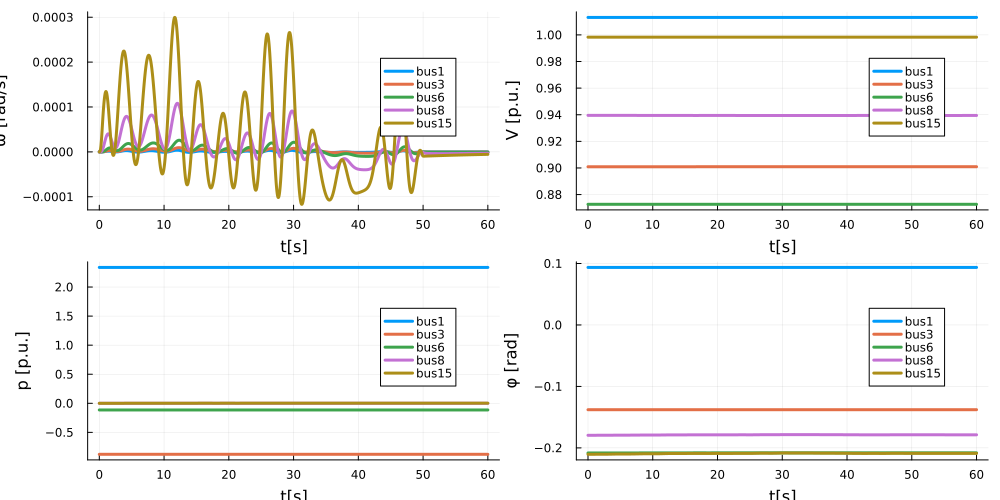

In [10]:
create_plot(solution1, ieee15)

0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0
0.0:0.006000600060006:60.0


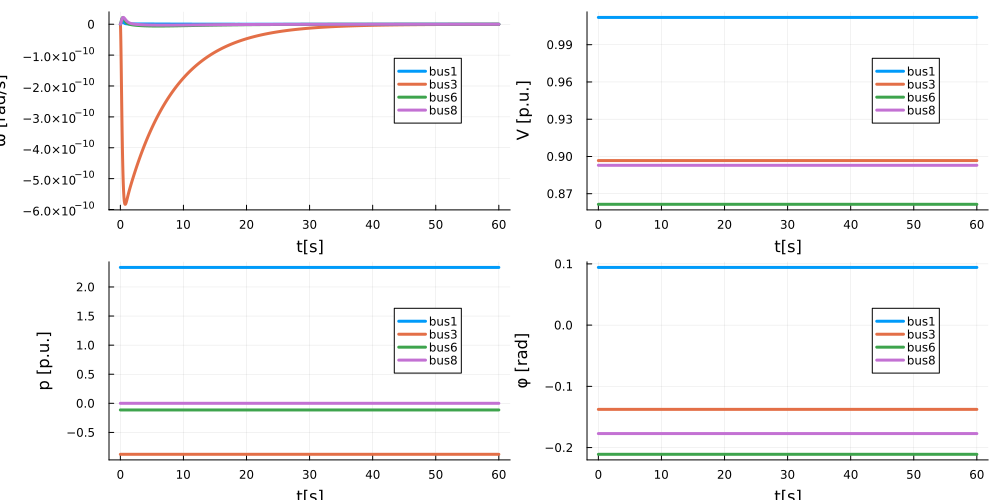

In [11]:
create_plot(solution2, ieee14)

In [ ]:
plot_bus_compare(solution1, solution2, "bus8")

In [3]:
### fault test: 

operationpoint1 = find_operationpoint(ieee15)

config = Dict(
    "fault_span" => (30, 45),
    "component" => "bus8",
    "timespan" => (0.0, 50.0)
)
fault1 = NodeParameterChange(node = config["component"], tspan_fault = config["fault_span"], value=1.0, var=:P)

# run dynamic simulation
solution1 = simulate(fault1, ieee15, operationpoint1, config["timespan"])

########################################################

operationpoint2 = find_operationpoint(ieee14)

fault2 = NodeParameterChange(node = config["component"], tspan_fault = config["fault_span"], value=1.0, var=:P)

# run dynamic simulation
solution2 = simulate(fault2, ieee14, operationpoint2, config["timespan"])


UndefVarError: UndefVarError: `find_operationpoint` not defined

In [2]:
plot_bus_compare(solution1, solution2, "bus8")

UndefVarError: UndefVarError: `solution1` not defined

0.0:0.005000500050005001:50.0
0.0:0.005000500050005001:50.0
0.0:0.005000500050005001:50.0
0.0:0.005000500050005001:50.0
0.0:0.005000500050005001:50.0


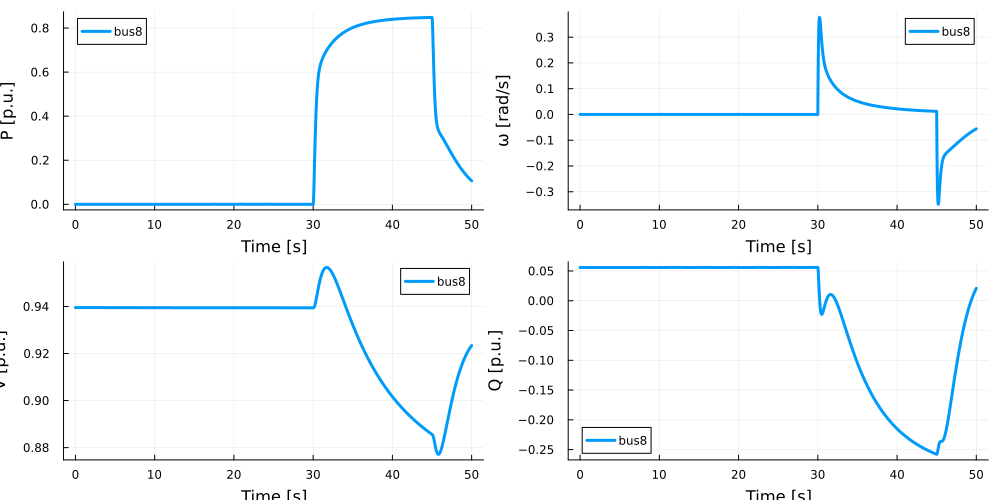

In [44]:
### fault test: 

operationpoint = find_operationpoint(ieee15)

# Configuration for the simulation
# notice the fault span is after the simulation start time to run a flat run
config = Dict(
    "fault_span" => (30, 45),
    "component" => "bus8",
    "timespan" => (0.0, 50.0)
)
fault = NodeParameterChange(node = config["component"], tspan_fault = config["fault_span"], value=1.0, var=:P)

# run dynamic simulation
solution = simulate(fault, ieee15, operationpoint, config["timespan"])

create_plot(solution, ieee15)
plot_bus(solution, "bus15")
plot_bus(solution, "bus8")

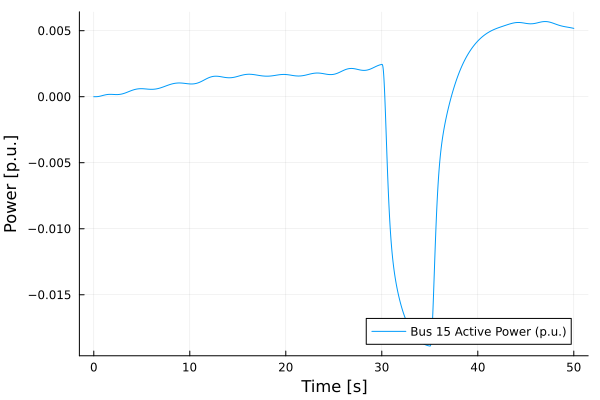

In [8]:
# 1. Collect the bus‑15 active power from the simulation (already in p.u.)
t_sim   = solution.dqsol.t
p_bus15 = [solution(t, "bus15", :p) for t in t_sim]

# 3. Plot them together
plot(t_sim, p_bus15,
     label = "Bus 15 Active Power (p.u.)",
     xlabel = "Time [s]", ylabel = "Power [p.u.]")


In [22]:
pte = 0.8 *  (1 / 100e6).* series.pto_power_wec  # per-unit reference
pbus15 = sim_state[:, "bus15", :p]                # per-unit active power from sim

plot(sim_time, pbus15, label="Bus15 active power (p.u.)")
plot!(sim_time, pte, label="η * scaling_factor * PTO power (p.u.)")


UndefVarError: UndefVarError: `sim_state` not defined

In [ ]:
# using Pkg
# Pkg.activate("./env")

# using ImportAll
# @importall(MarinePowerDynamics)

# using CSV
# using DataFrames
# using Plots
# using JSON

  Activating project at `~/research/MarinePowerDynamics.jl/example/env`
┌ Warning: attempting to remove probably stale pidfile
│   path = /Users/alex_barajas/.julia/compiled/v1.10/MarinePowerDynamics/PwLJy_rYaBI.ji.pidfile
└ @ FileWatching.Pidfile /Users/alex_barajas/.julia/juliaup/julia-1.10.4+0.aarch64.apple.darwin14/share/julia/stdlib/v1.10/FileWatching/src/pidfile.jl:244


In [21]:
function load_linear_pto_json(path::AbstractString)
    payload = JSON.parsefile(path)

    meta = payload["meta"]

    data = payload["data"]
    time  = Float64.(data["time"])
    disp  = Float64.(data["relativeDisplacement"])
    vel   = Float64.(data["relativeVelocity"])
    f_wec = Float64.(data["ptoForceWEC"])
    p_wec = Float64.(data["ptoPowerWEC"])
    wave  = Float64.(data["waveElevation"])

    df = DataFrame(
        time              = time,
        relative_disp     = disp,
        relative_vel      = vel,
        pto_force_wec     = f_wec,
        pto_power_wec     = p_wec,
        wave_elevation    = wave,
    )

    return meta, df
end

meta, series = load_linear_pto_json("RM3/linear_pto_heave.json")
print(meta)
series

Dict{String, Any}("startTime" => 0, "bodies" => Dict{String, Any}("names" => Any["float", "spar"]), "exportVersion" => 1, "Cpto" => 1.2e6, "timeStep" => 0.1, "ptoName" => "PTO1", "endTime" => 50, "wave" => Dict{String, Any}("height" => 2.5, "period" => 8, "phaseSeed" => 0, "direction" => 0, "type" => "", "spectrum" => "PM"), "relativeDOF" => "heave", "generatedAt" => "2025-09-18T20:26:12", "waveSource" => "waves.waveAmpTime", "constraints" => Dict{String, Any}("names" => Any["Constraint1"]), "Kpto" => 0, "powerSource" => "model (fallback)", "samples" => 500, "forceSource" => "model (fallback)", "simulation" => Dict{String, Any}("stateSpace" => 0, "mode" => "normal", "rampTime" => 0, "solver" => "ode4", "modelFile" => "/Users/alex_barajas/research/WEC-Sim-7.0.0/examples/RM3/RM3.slx"), "pto" => Dict{String, Any}("forceField" => "model (fallback)", "name" => "PTO1", "location" => Any[0, 0, 0], "stiffness" => 0, "powerField" => "model (fallback)", "damping" => 1.2e6))

Row,time,relative_disp,relative_vel,pto_force_wec,pto_power_wec,wave_elevation
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,20.57,0.0,0.0,0.0,-0.561654
2,0.1,20.5666,-0.071662,85994.4,6162.52,-0.690081
3,0.2,20.5552,-0.158376,1.90052e5,30099.7,-0.821761
4,0.3,20.5348,-0.249746,2.99695e5,74847.5,-0.953394
5,0.4,20.5056,-0.333467,4.00161e5,1.33441e5,-1.08108
6,0.5,20.4686,-0.40241,4.82893e5,194321.0,-1.20063
7,0.6,20.4256,-0.455303,5.46364e5,2.48761e5,-1.30787
8,0.7,20.378,-0.494018,5.92822e5,292865.0,-1.39899
9,0.8,20.3272,-0.520723,6.24867e5,3.25383e5,-1.47079


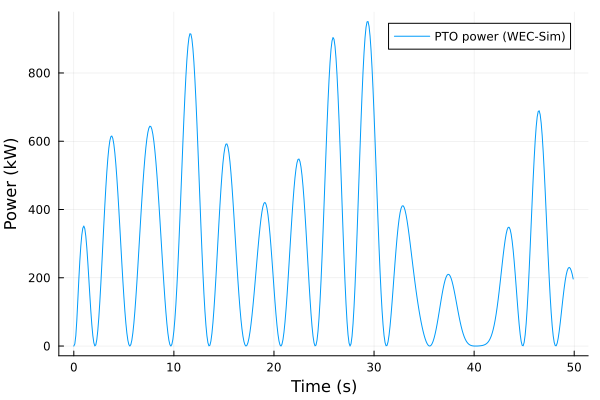

In [19]:
plot(
    series.time,
    series.pto_power_wec ./ 1_000,
    xlabel = "Time (s)",
    ylabel = "Power (kW)",
    label = "PTO power (WEC-Sim)",
)

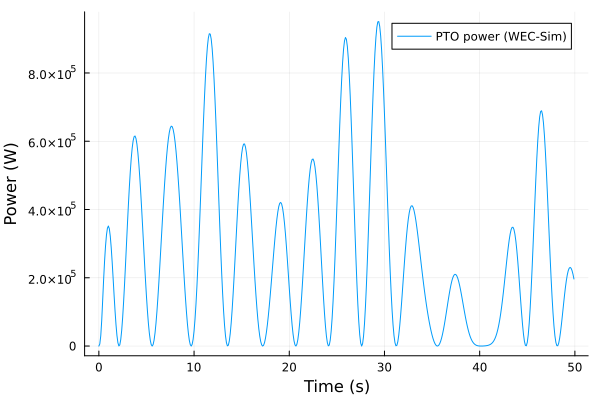

In [18]:
plot(
    series.time,
    series.pto_power_wec,
    xlabel = "Time (s)",
    ylabel = "Power (W)",
    label = "PTO power (WEC-Sim)"
)
